# Phase 3: Explainability Analysis with Novel Contributions

**Objective:** Provide multi-layered explainability for the Phase 1 predictive model, incorporating four novel research contributions:

1. **Multi-Method Explainability Consensus Framework** — Fidelity-weighted unification of SHAP, LIME, and Permutation Importance with confidence intervals
2. **Explanation Stability & Robustness Analysis** — Quantitative evaluation of LIME stochasticity, SHAP perturbation sensitivity, and cross-method rank agreement
3. **Category-Stratified Explainability** — Per-domain SHAP profiles with Kruskal-Wallis significance testing
4. **Counterfactual Explanations** — Minimal feature-change sets to transition slow/medium pages to fast

**Model:** XGBoost (22 features = 14 base + 8 engineered), 90.60% test accuracy  
**Dataset:** 885 URLs, 3 classes (fast / medium / slow)

## 1. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Model and preprocessing
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

# Explainability libraries
import shap
from lime import lime_tabular

# Statistical testing
from scipy import stats
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
from itertools import combinations

print('All libraries imported successfully')
print(f'SHAP version: {shap.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

All libraries imported successfully
SHAP version: 0.50.0
NumPy version: 2.3.5
Pandas version: 2.3.3


## 2. Load Model and Prepare Data

In [2]:
# Load the Phase 1 XGBoost model
model_pkg = joblib.load('best_model_xgboost_20260225_114145.joblib')

model       = model_pkg['model']
scaler      = model_pkg['scaler']
encoders    = model_pkg['encoders']
feature_names = model_pkg['feature_names']   # 22 features

target_encoder   = encoders['target']
category_encoder = encoders.get('Category', None)
class_names      = list(target_encoder.classes_)   # ['fast', 'medium', 'slow']

print(f'Model:    {model_pkg["model_name"]}')
print(f'Accuracy: {model_pkg["metrics"]["Accuracy"]:.4f}')
print(f'Features: {len(feature_names)}')
print(f'Classes:  {class_names}')
print(f'\nFeature list:')
for i, f in enumerate(feature_names):
    print(f'  {i+1:2d}. {f}')

Model:    XGBoost
Accuracy: 0.9060
Features: 22
Classes:  ['fast', 'medium', 'slow']

Feature list:
   1. Category
   2. Page Size (KB)
   3. Load Time(s)
   4. Response Time(s)
   5. Throughput
   6. performance_score
   7. lcp
   8. fcp
   9. cls
  10. tti
  11. tbt
  12. speed_index
  13. total_byte_weight
  14. num_requests
  15. Size_LoadTime_Ratio
  16. Total_Time
  17. Throughput_ResponseTime_Ratio
  18. Log_Page_Size
  19. Log_Throughput
  20. CWV_Composite
  21. TBT_TTI_Ratio
  22. Bytes_Per_Request


In [3]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_website_performance_dataset_20251207_145008.csv')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nPerformance_Label distribution:')
print(df['Performance_Label'].value_counts())

Dataset: 885 rows, 27 columns

Performance_Label distribution:
Performance_Label
slow      315
fast      299
medium    271
Name: count, dtype: int64


In [4]:
def engineer_features(X_df):
    """
    Replicate the exact 8 engineered features from Phase 1.
    Input must be a DataFrame with the 14 base feature columns.
    Returns the same DataFrame with 8 new columns appended (22 total).
    """
    X = X_df.copy()
    X['Size_LoadTime_Ratio']          = X['Page Size (KB)'] / (X['Load Time(s)'] + 1e-6)
    X['Total_Time']                   = X['Response Time(s)'] + X['Load Time(s)']
    X['Throughput_ResponseTime_Ratio'] = X['Throughput'] / (X['Response Time(s)'] + 1e-6)
    X['Log_Page_Size']                = np.log1p(X['Page Size (KB)'])
    X['Log_Throughput']               = np.log1p(X['Throughput'])
    X['CWV_Composite']               = (X['lcp'] + X['fcp'] + X['tti']) / 3
    X['TBT_TTI_Ratio']               = X['tbt'] / (X['tti'] + 1e-6)
    X['Bytes_Per_Request']            = X['total_byte_weight'] / (X['num_requests'] + 1e-6)
    return X


# --- Prepare X, y ----------------------------------------------------------
BASE_FEATURES = feature_names[:14]          # 14 base features

df_work = df.dropna(subset=['Performance_Label']).copy()

# Encode Category
if category_encoder is not None and 'Category' in df_work.columns:
    known = set(category_encoder.classes_)
    df_work['Category'] = df_work['Category'].fillna(category_encoder.classes_[0])
    df_work['Category'] = df_work['Category'].apply(lambda x: x if x in known else category_encoder.classes_[0])
    df_work['Category'] = category_encoder.transform(df_work['Category'])

# Keep the original (unencoded) category for stratified analysis later
df_raw = df.dropna(subset=['Performance_Label']).copy()
category_raw = df_raw['Category'].copy().reset_index(drop=True)

# Build feature matrix
X_base = df_work[BASE_FEATURES].copy()
X_base.fillna(X_base.median(), inplace=True)
X_original = engineer_features(X_base)

assert list(X_original.columns) == feature_names, \
    f'Feature mismatch: got {list(X_original.columns)}, expected {feature_names}'

X_original = X_original.reset_index(drop=True)
X_scaled   = scaler.transform(X_original)
y          = target_encoder.transform(df_work['Performance_Label'].values)

print(f'X_scaled shape:  {X_scaled.shape}  (should be (N, 22))')
print(f'y shape:         {y.shape}')
print(f'Classes:         {np.unique(y)} -> {class_names}')
print(f'Feature check:   {len(feature_names)} features OK')

X_scaled shape:  (885, 22)  (should be (N, 22))
y shape:         (885,)
Classes:         [0 1 2] -> ['fast', 'medium', 'slow']
Feature check:   22 features OK


## 3. SHAP Global Analysis

In [5]:
# Compute SHAP values (TreeExplainer — exact for tree models)
shap_explainer = shap.TreeExplainer(model)
shap_values    = shap_explainer.shap_values(X_scaled)

# Normalise format: list of 2-D arrays, one per class
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_list = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
else:
    shap_values_list = shap_values

print(f'SHAP values computed: {len(shap_values_list)} classes, '
      f'each {shap_values_list[0].shape}')

SHAP values computed: 3 classes, each (885, 22)


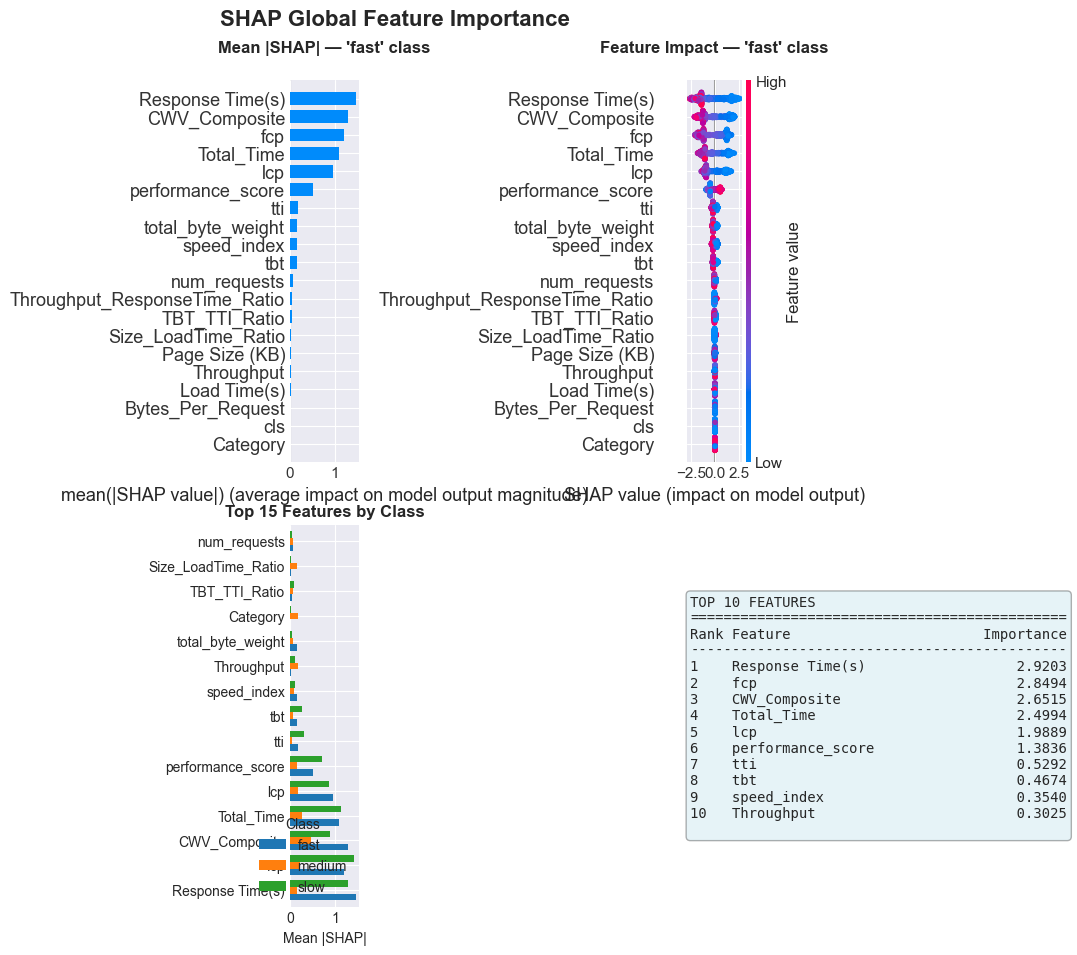


Top feature: Response Time(s) (2.9203)
Top-3 share: 52.8%


In [6]:
# --- Global SHAP visualisations -------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP Global Feature Importance', fontsize=16, fontweight='bold')

# 1. Bar plot — fast class
plt.sca(axes[0, 0])
shap.summary_plot(shap_values_list[0], X_scaled,
                  feature_names=feature_names, show=False, plot_type='bar')
axes[0, 0].set_title("Mean |SHAP| — 'fast' class", fontweight='bold', pad=20)

# 2. Beeswarm — fast class
plt.sca(axes[0, 1])
shap.summary_plot(shap_values_list[0], X_scaled,
                  feature_names=feature_names, show=False, plot_type='dot')
axes[0, 1].set_title("Feature Impact — 'fast' class", fontweight='bold', pad=20)

# 3. Per-class importance (top 15)
mean_shap_per_class = pd.DataFrame(
    {cn: np.abs(shap_values_list[i]).mean(axis=0) for i, cn in enumerate(class_names)},
    index=feature_names
)
mean_shap_per_class['total'] = mean_shap_per_class.sum(axis=1)
top15 = mean_shap_per_class.nlargest(15, 'total')[class_names]
top15.plot.barh(ax=axes[1, 0], width=0.8)
axes[1, 0].set_xlabel('Mean |SHAP|')
axes[1, 0].set_title('Top 15 Features by Class', fontweight='bold')
axes[1, 0].legend(title='Class', loc='lower right')

# 4. Summary table
axes[1, 1].axis('off')
overall = mean_shap_per_class['total'].nlargest(10)
tbl = 'TOP 10 FEATURES\n' + '='*45 + '\n'
tbl += f'{"Rank":<5}{"Feature":<30}{"Importance":>10}\n' + '-'*45 + '\n'
for r, (f, v) in enumerate(overall.items(), 1):
    tbl += f'{r:<5}{f:<30}{v:>10.4f}\n'
axes[1, 1].text(0.05, 0.5, tbl, fontsize=10, family='monospace',
                va='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print(f'\nTop feature: {overall.index[0]} ({overall.iloc[0]:.4f})')
print(f'Top-3 share: {overall.iloc[:3].sum()/overall.sum()*100:.1f}%')

## 4. LIME Local Analysis

In [7]:
# Create LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_original.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

def lime_predict_fn(X_raw):
    """LIME passes unscaled data; we must scale before prediction."""
    return model.predict_proba(scaler.transform(X_raw))

# Select representative samples: one per class + one misclassified
preds = model.predict(X_scaled)
sample_indices = []

for cls_id in range(3):
    correct = np.where((y == cls_id) & (preds == cls_id))[0]
    if len(correct) > 0:
        sample_indices.append(correct[0])

misclassified = np.where(preds != y)[0]
if len(misclassified) > 0:
    sample_indices.append(misclassified[0])

print(f'Selected {len(sample_indices)} samples for LIME analysis: {sample_indices}')

# Generate LIME explanations
lime_explanations = []
for idx in sample_indices:
    exp = lime_explainer.explain_instance(
        X_original.iloc[idx].values, lime_predict_fn,
        num_features=10, top_labels=3
    )
    lime_explanations.append(exp)

    pred_cls = preds[idx]
    true_cls = y[idx]
    proba = model.predict_proba(X_scaled[idx:idx+1])[0]
    print(f'\nSample {idx}: true={class_names[true_cls]}, '
          f'pred={class_names[pred_cls]}, proba={np.round(proba,3)}')
    for feat, w in exp.as_list(label=pred_cls)[:5]:
        direction = 'INCREASES' if w > 0 else 'DECREASES'
        print(f'  {direction} prob: {feat}  (weight={w:+.4f})')

Selected 4 samples for LIME analysis: [np.int64(1), np.int64(0), np.int64(4), np.int64(55)]

Sample 1: true=fast, pred=fast, proba=[0.993 0.007 0.   ]
  INCREASES prob: CWV_Composite <= 1374.08  (weight=+0.3726)
  INCREASES prob: Response Time(s) <= 0.39  (weight=+0.3266)
  INCREASES prob: Total_Time <= 1.58  (weight=+0.2352)
  DECREASES prob: 805.21 < fcp <= 1068.75  (weight=-0.1652)
  INCREASES prob: performance_score > 87.00  (weight=+0.0647)

Sample 0: true=medium, pred=medium, proba=[0.108 0.887 0.005]
  INCREASES prob: 1374.08 < CWV_Composite <= 2282.25  (weight=+0.1109)
  DECREASES prob: Total_Time > 4.17  (weight=-0.1081)
  DECREASES prob: lcp <= 1102.01  (weight=-0.0972)
  INCREASES prob: 576.20 < fcp <= 805.21  (weight=+0.0911)
  INCREASES prob: 0.39 < Response Time(s) <= 0.73  (weight=+0.0567)

Sample 4: true=slow, pred=slow, proba=[0.    0.16  0.839]
  INCREASES prob: Response Time(s) > 1.17  (weight=+0.2422)
  INCREASES prob: performance_score <= 51.00  (weight=+0.1887)
  

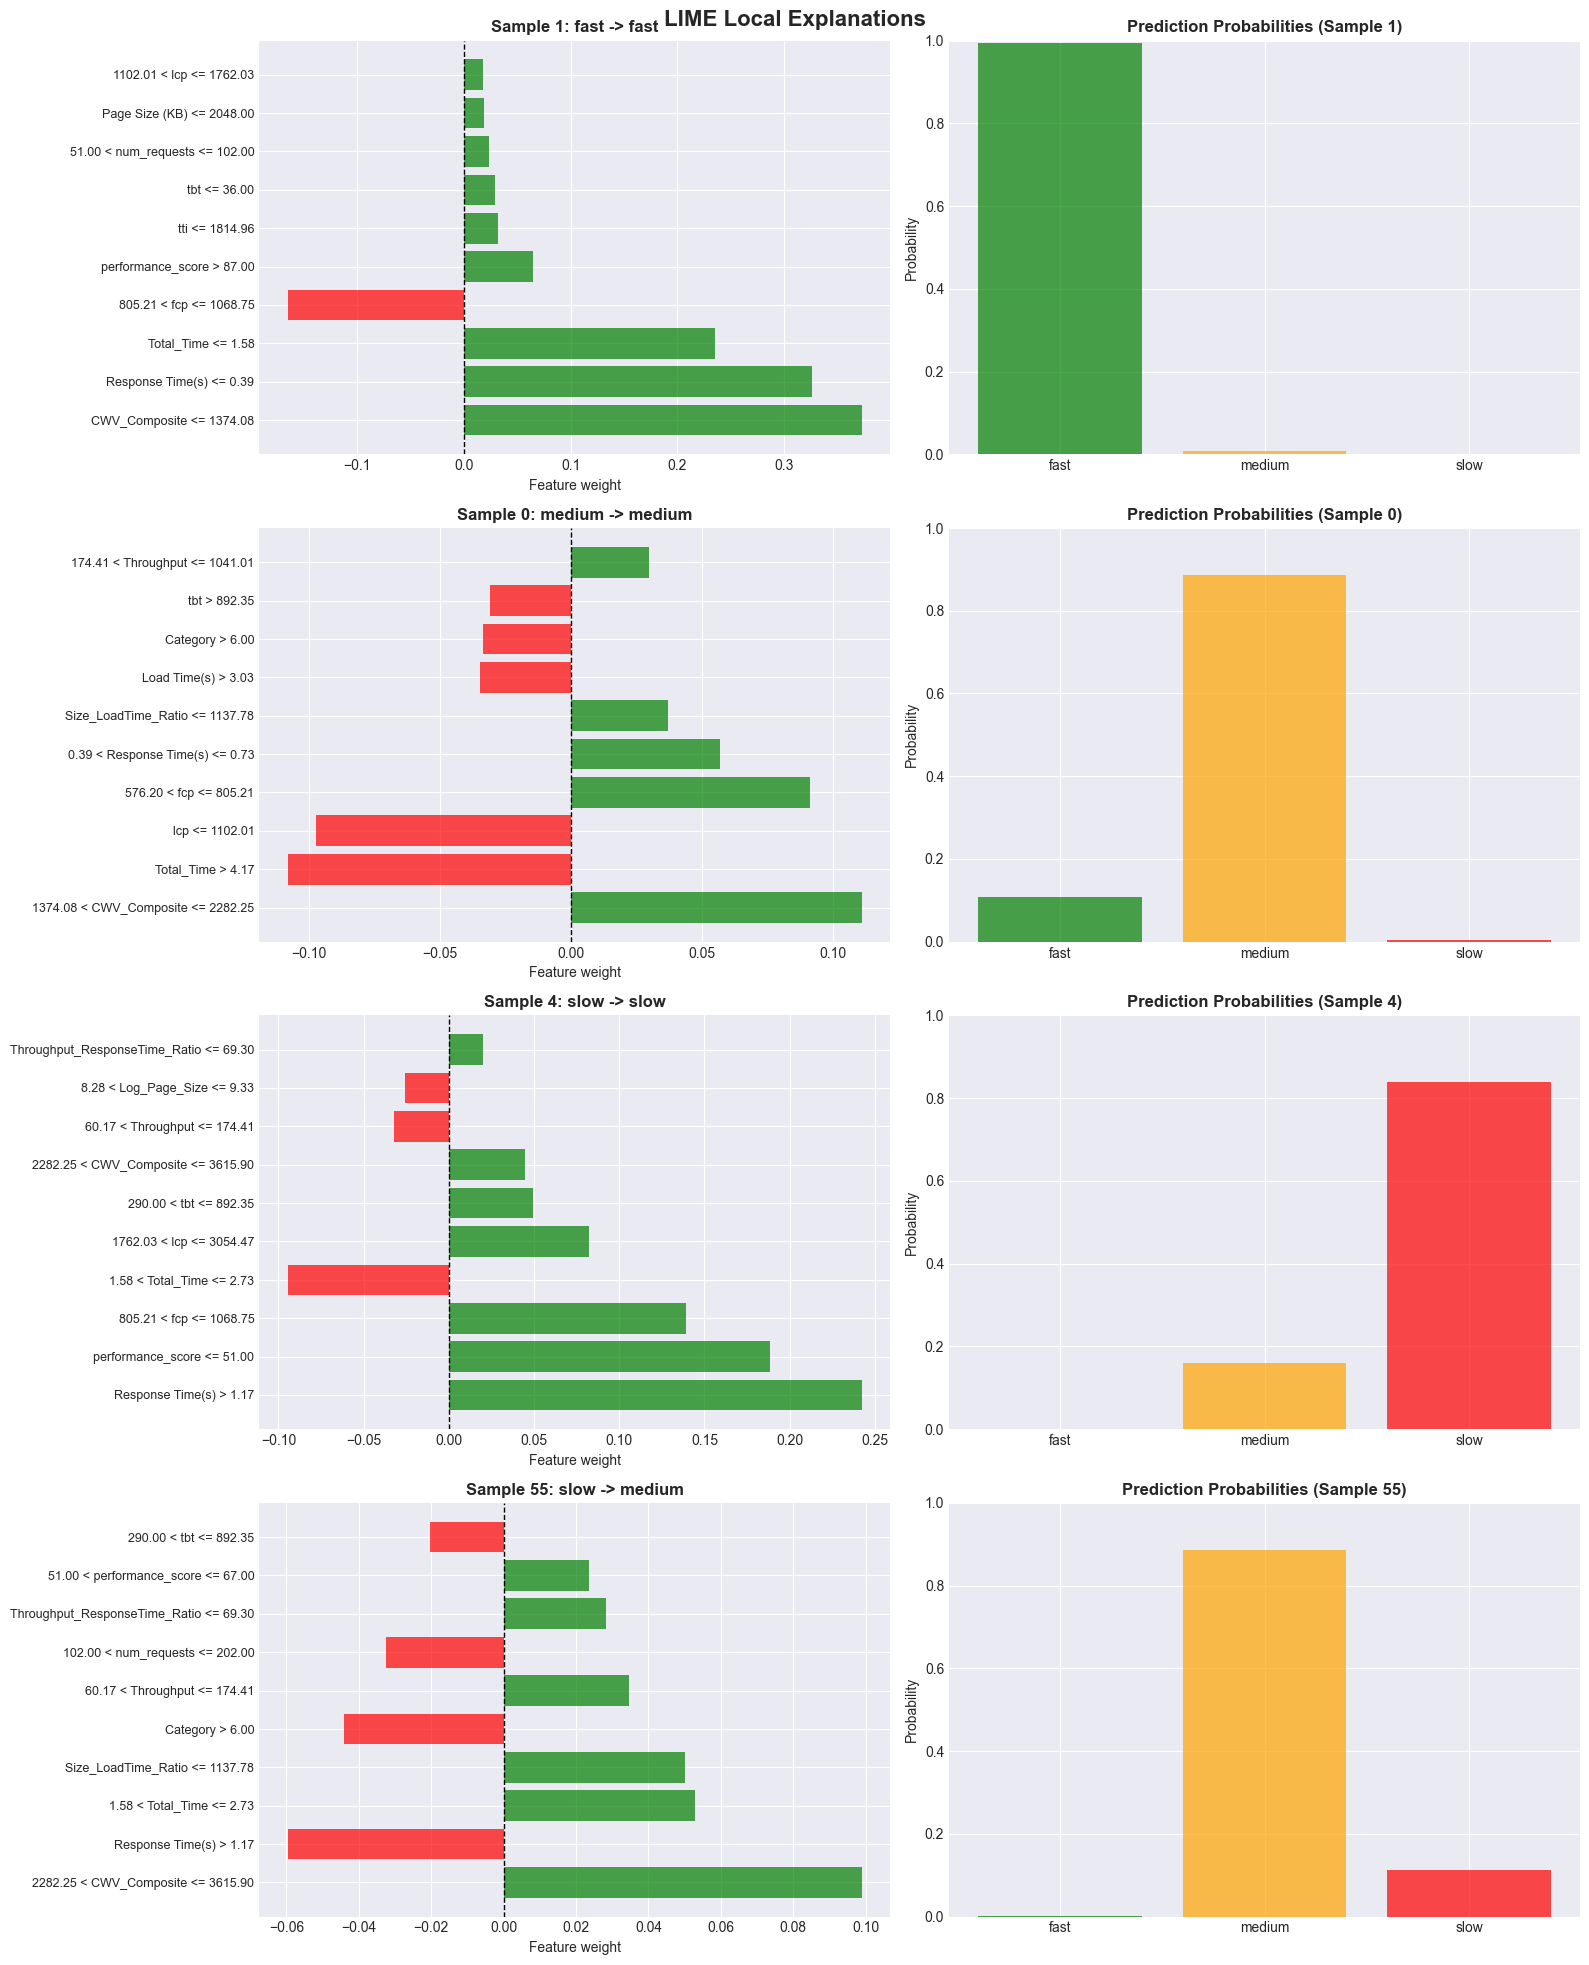

In [8]:
# Visualise LIME explanations
n = len(lime_explanations)
fig, axes = plt.subplots(n, 2, figsize=(16, 5*n))
if n == 1:
    axes = axes.reshape(1, -1)
fig.suptitle('LIME Local Explanations', fontsize=16, fontweight='bold')

for i, (exp, idx) in enumerate(zip(lime_explanations, sample_indices)):
    pred_cls = preds[idx]
    true_cls = y[idx]
    proba    = model.predict_proba(X_scaled[idx:idx+1])[0]

    exp_list = exp.as_list(label=pred_cls)[:10]
    feats  = [e[0] for e in exp_list]
    wts    = [e[1] for e in exp_list]
    colors = ['green' if w > 0 else 'red' for w in wts]

    axes[i, 0].barh(range(len(feats)), wts, color=colors, alpha=0.7)
    axes[i, 0].set_yticks(range(len(feats)))
    axes[i, 0].set_yticklabels(feats, fontsize=9)
    axes[i, 0].axvline(0, color='black', ls='--', lw=1)
    axes[i, 0].set_xlabel('Feature weight')
    axes[i, 0].set_title(f'Sample {idx}: {class_names[true_cls]} -> {class_names[pred_cls]}',
                         fontweight='bold')

    axes[i, 1].bar(class_names, proba, color=['green','orange','red'], alpha=0.7)
    axes[i, 1].set_ylabel('Probability')
    axes[i, 1].set_ylim([0, 1])
    axes[i, 1].set_title(f'Prediction Probabilities (Sample {idx})', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5. NOVEL CONTRIBUTION 1 — Multi-Method Explainability Consensus Framework

**Motivation:** SHAP and LIME are the two dominant post-hoc XAI methods, yet they often
disagree on feature rankings. Practitioners are left without guidance on which to trust.
We propose a *fidelity-weighted consensus framework* that:

1. Computes global importance from **three independent methods**: SHAP, LIME (aggregated local), and Permutation Importance.
2. Measures each method's **local fidelity** (how faithfully it approximates the model).
3. Produces a **fidelity-weighted consensus ranking** with confidence intervals.
4. Quantifies inter-method agreement via **rank correlation** (Kendall's τ, Spearman's ρ).

In [9]:
# --- 5a. Permutation Importance -------------------------------------------
print('Computing Permutation Importance (5-fold, 10 repeats each)...')

perm_result = permutation_importance(
    model, X_scaled, y,
    n_repeats=10, random_state=42, scoring='accuracy'
)

perm_importance = perm_result.importances_mean            # shape (22,)
perm_importance_std = perm_result.importances_std

print('Permutation Importance computed.')
for i in np.argsort(perm_importance)[::-1][:5]:
    print(f'  {feature_names[i]:30s}  {perm_importance[i]:.4f} +/- {perm_importance_std[i]:.4f}')

Computing Permutation Importance (5-fold, 10 repeats each)...
Permutation Importance computed.
  Response Time(s)                0.1584 +/- 0.0082
  fcp                             0.1208 +/- 0.0101
  CWV_Composite                   0.1113 +/- 0.0085
  Total_Time                      0.1003 +/- 0.0059
  lcp                             0.0469 +/- 0.0070


In [10]:
# --- 5b. LIME-based Global Importance (aggregated) -------------------------
# Run LIME on K random samples and average absolute weights per feature.

K_LIME = 80   # number of samples for aggregation
np.random.seed(42)
lime_sample_idx = np.random.choice(len(X_original), size=min(K_LIME, len(X_original)), replace=False)

print(f'Running LIME on {len(lime_sample_idx)} samples for global aggregation...')

lime_weights_all = np.zeros((len(lime_sample_idx), len(feature_names)))
lime_r2_scores   = []

for j, idx in enumerate(lime_sample_idx):
    exp = lime_explainer.explain_instance(
        X_original.iloc[idx].values, lime_predict_fn,
        num_features=len(feature_names), top_labels=1
    )
    pred_cls = preds[idx]
    # Extract weights keyed by feature name
    weight_dict = dict(exp.as_list(label=pred_cls))
    for fi, fn in enumerate(feature_names):
        # LIME feature rules contain the feature name as substring
        for rule, w in weight_dict.items():
            if fn in rule:
                lime_weights_all[j, fi] = w
                break
    # Record LIME's local R^2  (fidelity)
    lime_r2_scores.append(exp.score)
    if (j + 1) % 20 == 0:
        print(f'  {j+1}/{len(lime_sample_idx)} done')

lime_global_importance = np.abs(lime_weights_all).mean(axis=0)
lime_mean_r2 = np.mean(lime_r2_scores)

print(f'\nLIME aggregated. Mean local R^2 (fidelity): {lime_mean_r2:.4f}')

Running LIME on 80 samples for global aggregation...
  20/80 done
  40/80 done
  60/80 done
  80/80 done

LIME aggregated. Mean local R^2 (fidelity): 0.2806


In [11]:
# --- 5c. SHAP fidelity check -----------------------------------------------
# For TreeExplainer, SHAP values are exact (sum to prediction margin).
# We verify: base_value + sum(shap_values) ~ predicted log-odds

base_values = shap_explainer.expected_value
if isinstance(base_values, (list, np.ndarray)):
    bv = base_values[0]   # fast class
else:
    bv = base_values

shap_fast = shap_values_list[0]            # (N, 22)
reconstructed = bv + shap_fast.sum(axis=1)  # should match raw model output margin for class 0

# The raw output for XGBoost multiclass is the softmax input (log-odds like)
raw_pred = model.predict(X_scaled, output_margin=True)
if raw_pred.ndim == 2:
    raw_class0 = raw_pred[:, 0]
else:
    raw_class0 = raw_pred

shap_error = np.abs(reconstructed - raw_class0)
shap_fidelity = 1.0 - shap_error.mean()   # ~1.0 for TreeExplainer

print(f'SHAP additivity check:')
print(f'  Mean absolute error:  {shap_error.mean():.6f}')
print(f'  Max absolute error:   {shap_error.max():.6f}')
print(f'  Fidelity score:       {shap_fidelity:.6f}')

SHAP additivity check:
  Mean absolute error:  0.000002
  Max absolute error:   0.000007
  Fidelity score:       0.999998


In [12]:
# --- 5d. Fidelity-Weighted Consensus Ranking --------------------------------

# Normalise each method's importance to [0, 1] range
def normalise(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-12)

shap_global = np.abs(shap_fast).mean(axis=0)   # mean |SHAP| for fast class

imp_shap = normalise(shap_global)
imp_lime = normalise(lime_global_importance)
imp_perm = normalise(perm_importance)

# Fidelity weights
w_shap = min(shap_fidelity, 1.0)        # TreeExplainer -> ~1.0
w_lime = max(lime_mean_r2, 0.0)          # LIME local R^2
w_perm = 1.0                              # Permutation is model-agnostic ground truth

total_w = w_shap + w_lime + w_perm
w_shap_n = w_shap / total_w
w_lime_n = w_lime / total_w
w_perm_n = w_perm / total_w

print(f'Fidelity weights (normalised):')
print(f'  SHAP:        {w_shap_n:.4f}  (raw fidelity={w_shap:.4f})')
print(f'  LIME:        {w_lime_n:.4f}  (raw R^2={w_lime:.4f})')
print(f'  Permutation: {w_perm_n:.4f}  (reference=1.0)')

# Weighted consensus
consensus = w_shap_n * imp_shap + w_lime_n * imp_lime + w_perm_n * imp_perm

# Confidence interval: range of the 3 methods
stacked = np.stack([imp_shap, imp_lime, imp_perm], axis=0)  # (3, 22)
ci_low  = stacked.min(axis=0)
ci_high = stacked.max(axis=0)

consensus_df = pd.DataFrame({
    'Feature':        feature_names,
    'SHAP':           imp_shap,
    'LIME':           imp_lime,
    'Permutation':    imp_perm,
    'Consensus':      consensus,
    'CI_Low':         ci_low,
    'CI_High':        ci_high
}).sort_values('Consensus', ascending=False).reset_index(drop=True)

print('\nConsensus Feature Ranking:')
print(consensus_df.to_string(index=False, float_format='{:.4f}'.format))

Fidelity weights (normalised):
  SHAP:        0.4385  (raw fidelity=1.0000)
  LIME:        0.1230  (raw R^2=0.2806)
  Permutation: 0.4385  (reference=1.0)

Consensus Feature Ranking:
                      Feature   SHAP   LIME  Permutation  Consensus  CI_Low  CI_High
             Response Time(s) 1.0000 0.9506       1.0000     0.9939  0.9506   1.0000
                CWV_Composite 0.8797 1.0000       0.7074     0.8190  0.7074   1.0000
                          fcp 0.8244 0.8516       0.7663     0.8023  0.7663   0.8516
                   Total_Time 0.7496 0.6321       0.6393     0.6868  0.6321   0.7496
                          lcp 0.6463 0.5986       0.3074     0.4918  0.3074   0.6463
            performance_score 0.3440 0.4574       0.1221     0.2607  0.1221   0.4574
                          tti 0.1166 0.1027       0.0267     0.0754  0.0267   0.1166
                          tbt 0.1034 0.1278       0.0260     0.0724  0.0260   0.1278
            total_byte_weight 0.1086 0.0383       0.

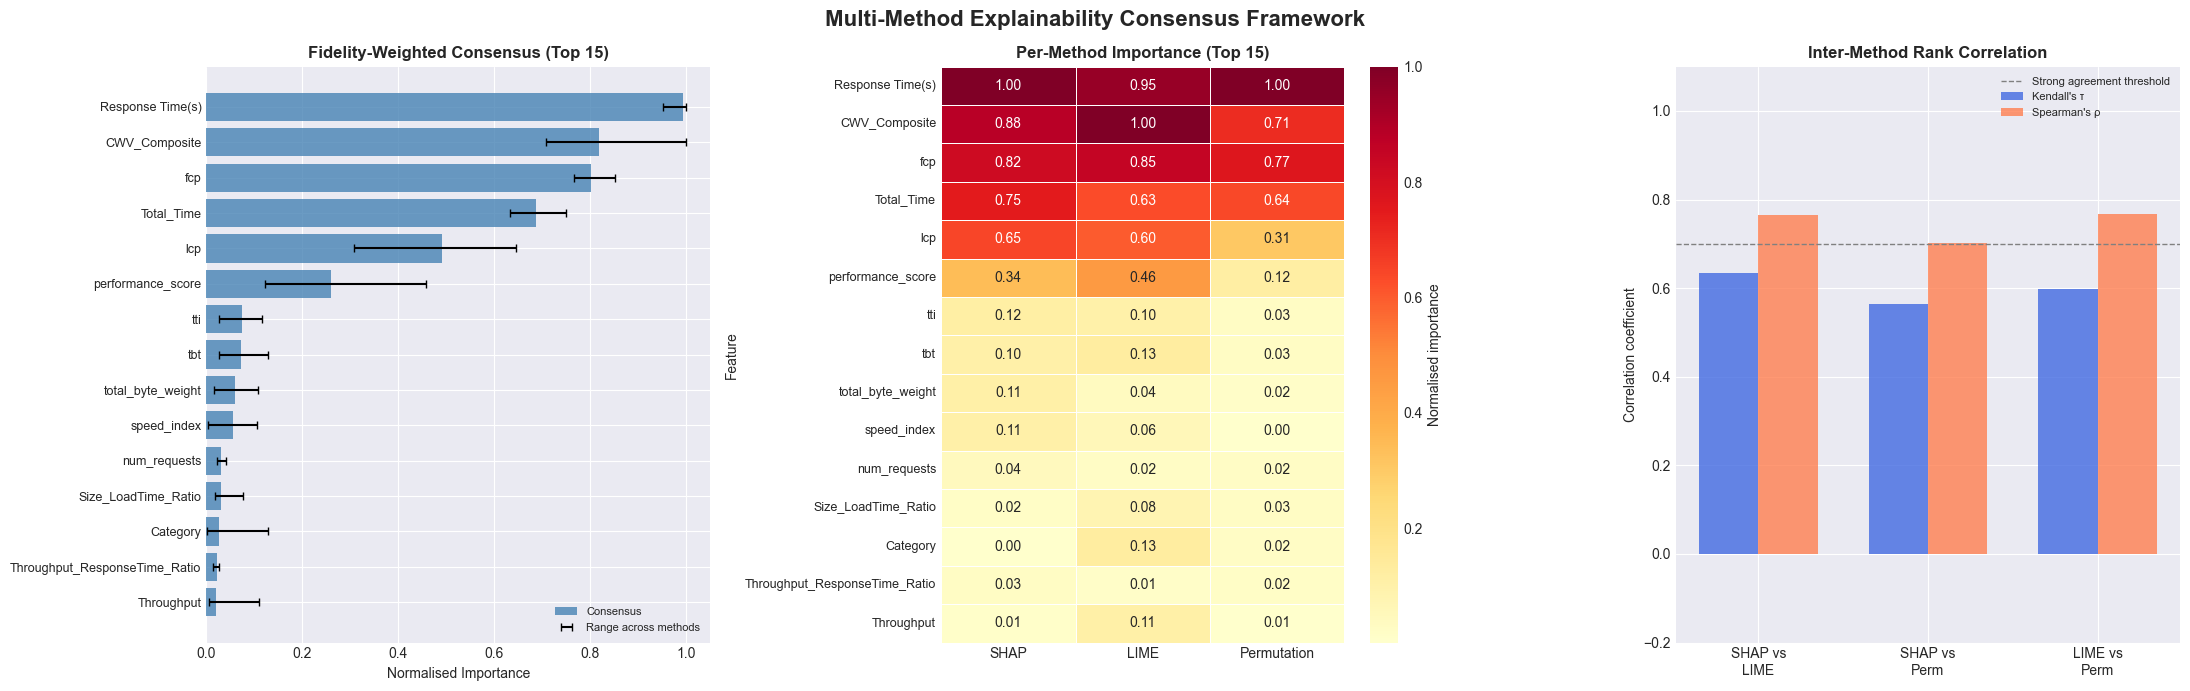


Rank correlations:
  SHAP vs LIME        tau=0.633  rho=0.766
  SHAP vs Perm        tau=0.565  rho=0.703
  LIME vs Perm        tau=0.599  rho=0.767


In [13]:
# --- 5e. Consensus and rank-correlation visualisation -----------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Multi-Method Explainability Consensus Framework',
             fontsize=16, fontweight='bold')

# 1. Consensus bar chart with CI
top_n = 15
top = consensus_df.head(top_n)
y_pos = range(top_n)

axes[0].barh(y_pos, top['Consensus'], color='steelblue', alpha=0.8, label='Consensus')
axes[0].errorbar(top['Consensus'], y_pos,
                 xerr=[top['Consensus'] - top['CI_Low'],
                       top['CI_High'] - top['Consensus']],
                 fmt='none', ecolor='black', capsize=3, label='Range across methods')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top['Feature'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Normalised Importance')
axes[0].set_title('Fidelity-Weighted Consensus (Top 15)', fontweight='bold')
axes[0].legend(fontsize=8)

# 2. Heatmap: normalised importance from each method
heat_data = consensus_df.set_index('Feature')[['SHAP','LIME','Permutation']].head(top_n)
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Normalised importance'})
axes[1].set_title('Per-Method Importance (Top 15)', fontweight='bold')
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=9)

# 3. Rank correlation
rank_shap = stats.rankdata(-imp_shap)
rank_lime = stats.rankdata(-lime_global_importance)
rank_perm = stats.rankdata(-perm_importance)

pairs = [('SHAP','LIME', rank_shap, rank_lime),
         ('SHAP','Perm', rank_shap, rank_perm),
         ('LIME','Perm', rank_lime, rank_perm)]

corr_labels = []
tau_vals = []
rho_vals = []
for name, name2, r1, r2 in pairs:
    tau, _ = stats.kendalltau(r1, r2)
    rho, _ = stats.spearmanr(r1, r2)
    corr_labels.append(f'{name} vs\n{name2}')
    tau_vals.append(tau)
    rho_vals.append(rho)

x_pos = np.arange(len(corr_labels))
w = 0.35
axes[2].bar(x_pos - w/2, tau_vals, w, label="Kendall's τ", color='royalblue', alpha=0.8)
axes[2].bar(x_pos + w/2, rho_vals, w, label="Spearman's ρ", color='coral', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(corr_labels, fontsize=10)
axes[2].set_ylabel('Correlation coefficient')
axes[2].set_ylim([-0.2, 1.1])
axes[2].axhline(0.7, ls='--', color='gray', lw=1, label='Strong agreement threshold')
axes[2].set_title('Inter-Method Rank Correlation', fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nRank correlations:')
for lbl, t, r in zip(corr_labels, tau_vals, rho_vals):
    print(f'  {lbl.replace(chr(10)," "):18s}  tau={t:.3f}  rho={r:.3f}')

---
## 6. NOVEL CONTRIBUTION 2 — Explanation Stability & Robustness Analysis

**Motivation:** LIME relies on stochastic perturbation sampling — running it twice on the
same instance can yield different feature rankings. SHAP (TreeExplainer) is deterministic,
but its values may be sensitive to small input perturbations. We quantify:

1. **LIME stability** — Jaccard similarity of top-*k* features across *N* independent runs.
2. **SHAP perturbation sensitivity** — L₂ drift in SHAP values under ±5% input noise.
3. **Cross-method rank agreement** — Kendall's τ between per-instance SHAP and LIME rankings, stratified by class.

In [14]:
# --- 6a. LIME Stability Test ------------------------------------------------
# For M samples, run LIME N times each. Compute Jaccard similarity of top-k
# feature sets across all (N choose 2) pairs of runs.

M_SAMPLES   = 30     # number of instances to test
N_RUNS      = 20     # LIME runs per instance
TOP_K       =  5     # top-k features for Jaccard

np.random.seed(42)
stability_indices = np.random.choice(len(X_original), size=M_SAMPLES, replace=False)

print(f'LIME Stability Test: {M_SAMPLES} samples x {N_RUNS} runs (top-{TOP_K} Jaccard)')

jaccard_per_sample = []

for s_idx, data_idx in enumerate(stability_indices):
    top_k_sets = []
    for run in range(N_RUNS):
        exp = lime_tabular.LimeTabularExplainer(
            training_data=X_original.values,
            feature_names=feature_names,
            class_names=class_names,
            mode='classification',
            discretize_continuous=True,
            random_state=run * 1000 + s_idx   # different seed each run
        ).explain_instance(
            X_original.iloc[data_idx].values, lime_predict_fn,
            num_features=TOP_K, top_labels=1
        )
        pred_cls = preds[data_idx]
        top_feats = set()
        for rule, _ in exp.as_list(label=pred_cls):
            for fn in feature_names:
                if fn in rule:
                    top_feats.add(fn)
                    break
        top_k_sets.append(top_feats)

    # Pairwise Jaccard
    jaccards = []
    for a, b in combinations(range(N_RUNS), 2):
        inter = len(top_k_sets[a] & top_k_sets[b])
        union = len(top_k_sets[a] | top_k_sets[b])
        jaccards.append(inter / union if union > 0 else 1.0)
    jaccard_per_sample.append(np.mean(jaccards))

    if (s_idx + 1) % 10 == 0:
        print(f'  {s_idx+1}/{M_SAMPLES} done  (mean Jaccard so far: {np.mean(jaccard_per_sample):.3f})')

lime_stability_index = np.mean(jaccard_per_sample)
lime_stability_std   = np.std(jaccard_per_sample)

print(f'\nLIME Stability Index (Jaccard):  {lime_stability_index:.4f} +/- {lime_stability_std:.4f}')
print(f'  Interpretation: 1.0 = perfectly stable, 0.0 = completely random')
if lime_stability_index >= 0.8:
    print('  -> LIME explanations are STABLE')
elif lime_stability_index >= 0.5:
    print('  -> LIME explanations show MODERATE stability')
else:
    print('  -> LIME explanations are UNSTABLE — interpret with caution')

LIME Stability Test: 30 samples x 20 runs (top-5 Jaccard)
  10/30 done  (mean Jaccard so far: 0.897)
  20/30 done  (mean Jaccard so far: 0.894)
  30/30 done  (mean Jaccard so far: 0.876)

LIME Stability Index (Jaccard):  0.8764 +/- 0.1048
  Interpretation: 1.0 = perfectly stable, 0.0 = completely random
  -> LIME explanations are STABLE


In [15]:
# --- 6b. SHAP Perturbation Sensitivity -------------------------------------
# Perturb each sample by +/- 5% Gaussian noise. Measure L2 distance in SHAP
# values between original and perturbed.

EPSILON     = 0.05     # perturbation magnitude
N_PERTURB   = 30       # number of samples

np.random.seed(42)
perturb_idx = np.random.choice(len(X_scaled), size=N_PERTURB, replace=False)

print(f'SHAP Perturbation Sensitivity: {N_PERTURB} samples, epsilon={EPSILON}')

shap_drift_per_sample = []

for idx in perturb_idx:
    original = X_scaled[idx:idx+1]
    noise    = np.random.randn(*original.shape) * EPSILON
    perturbed = original + noise

    sv_orig    = shap_explainer.shap_values(original)
    sv_perturb = shap_explainer.shap_values(perturbed)

    # Extract fast-class values
    if isinstance(sv_orig, np.ndarray) and sv_orig.ndim == 3:
        sv_o = sv_orig[0, :, 0]
        sv_p = sv_perturb[0, :, 0]
    elif isinstance(sv_orig, list):
        sv_o = sv_orig[0][0]
        sv_p = sv_perturb[0][0]
    else:
        sv_o = sv_orig[0]
        sv_p = sv_perturb[0]

    drift = np.linalg.norm(sv_o - sv_p)
    shap_drift_per_sample.append(drift)

shap_mean_drift = np.mean(shap_drift_per_sample)
shap_std_drift  = np.std(shap_drift_per_sample)

print(f'\nSHAP L2 Drift:  {shap_mean_drift:.4f} +/- {shap_std_drift:.4f}')
print(f'  Relative to mean SHAP magnitude: {shap_mean_drift / (np.abs(shap_fast).mean() + 1e-12):.2f}x')

SHAP Perturbation Sensitivity: 30 samples, epsilon=0.05

SHAP L2 Drift:  0.3278 +/- 0.2544
  Relative to mean SHAP magnitude: 0.97x


In [16]:
# --- 6c. Cross-Method Per-Instance Rank Agreement --------------------------
# For each instance in lime_sample_idx, rank features by |SHAP| and |LIME weight|.
# Compute Kendall's tau, stratified by predicted class.

print('Cross-Method Rank Agreement (per instance)...')

tau_per_class = {cn: [] for cn in class_names}

# Use the same sample set as section 5b (lime_sample_idx)
for j, idx in enumerate(lime_sample_idx):
    pred_cls = preds[idx]

    # SHAP ranking for this instance
    shap_inst = np.abs(shap_fast[idx])

    # LIME weights for this instance (already computed in 5b)
    lime_inst = np.abs(lime_weights_all[j])

    tau, _ = stats.kendalltau(shap_inst, lime_inst)
    if not np.isnan(tau):
        tau_per_class[class_names[pred_cls]].append(tau)

print('\nSHAP-LIME Kendall tau by predicted class:')
for cn in class_names:
    vals = tau_per_class[cn]
    if len(vals) > 0:
        print(f'  {cn:8s}: tau = {np.mean(vals):.3f} +/- {np.std(vals):.3f}  (n={len(vals)})')
    else:
        print(f'  {cn:8s}: no samples')

Cross-Method Rank Agreement (per instance)...

SHAP-LIME Kendall tau by predicted class:
  fast    : tau = 0.604 +/- 0.104  (n=30)
  medium  : tau = 0.342 +/- 0.102  (n=24)
  slow    : tau = 0.492 +/- 0.097  (n=26)


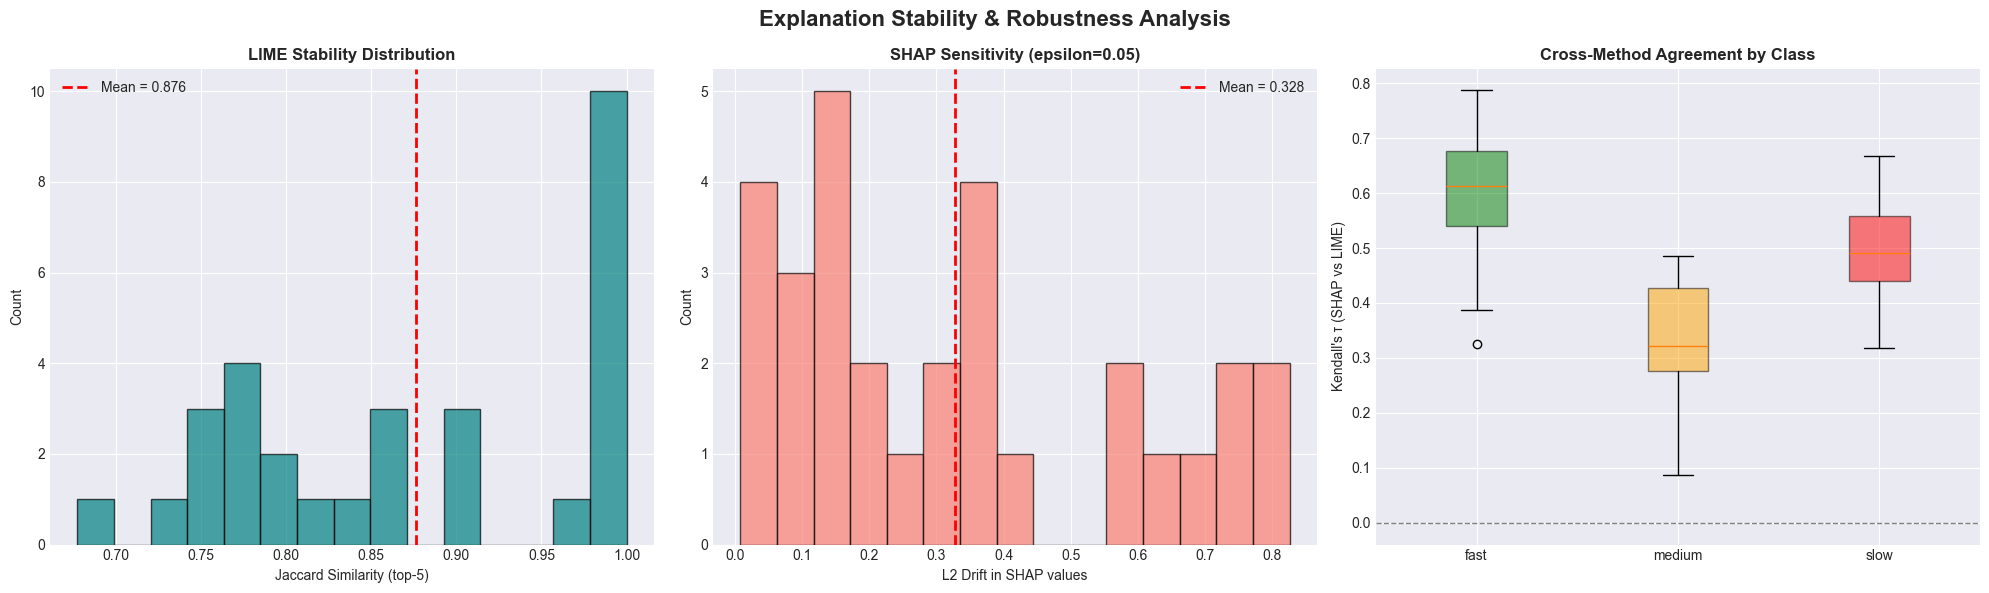

In [17]:
# --- 6d. Stability & Robustness Visualisation ------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Explanation Stability & Robustness Analysis',
             fontsize=16, fontweight='bold')

# 1. LIME stability histogram
axes[0].hist(jaccard_per_sample, bins=15, color='teal', alpha=0.7, edgecolor='black')
axes[0].axvline(lime_stability_index, color='red', ls='--', lw=2,
                label=f'Mean = {lime_stability_index:.3f}')
axes[0].set_xlabel(f'Jaccard Similarity (top-{TOP_K})')
axes[0].set_ylabel('Count')
axes[0].set_title('LIME Stability Distribution', fontweight='bold')
axes[0].legend()

# 2. SHAP perturbation drift histogram
axes[1].hist(shap_drift_per_sample, bins=15, color='salmon', alpha=0.7, edgecolor='black')
axes[1].axvline(shap_mean_drift, color='red', ls='--', lw=2,
                label=f'Mean = {shap_mean_drift:.3f}')
axes[1].set_xlabel('L2 Drift in SHAP values')
axes[1].set_ylabel('Count')
axes[1].set_title(f'SHAP Sensitivity (epsilon={EPSILON})', fontweight='bold')
axes[1].legend()

# 3. SHAP-LIME tau by class (box plot)
box_data = [tau_per_class[cn] for cn in class_names if len(tau_per_class[cn]) > 0]
box_labels = [cn for cn in class_names if len(tau_per_class[cn]) > 0]
bp = axes[2].boxplot(box_data, labels=box_labels, patch_artist=True)
colors_box = ['green', 'orange', 'red']
for patch, clr in zip(bp['boxes'], colors_box[:len(box_data)]):
    patch.set_facecolor(clr)
    patch.set_alpha(0.5)
axes[2].axhline(0.0, ls='--', color='gray', lw=1)
axes[2].set_ylabel("Kendall's τ (SHAP vs LIME)")
axes[2].set_title('Cross-Method Agreement by Class', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. NOVEL CONTRIBUTION 3 — Category-Stratified Explainability

**Motivation:** Existing web-performance XAI treats all websites as a homogeneous population.
In practice, different website categories (e-commerce, blog, news, etc.) have fundamentally
different architectures. We hypothesise that the model relies on *different features* for
different categories, meaning one-size-fits-all recommendations are sub-optimal.

**Method:**
1. Partition SHAP values by website category.
2. Compute per-category mean |SHAP| profiles.
3. Test for statistically significant differences using the Kruskal-Wallis H-test.
4. Visualise category-specific feature importance as a heatmap.

In [18]:
# --- 7a. Per-Category SHAP Profiles ----------------------------------------

# category_raw contains the original (text) category labels aligned to X_original
categories = category_raw.values
unique_cats = sorted([c for c in pd.Series(categories).dropna().unique()])

print(f'Categories found: {len(unique_cats)}')
for c in unique_cats:
    n = (categories == c).sum()
    print(f'  {c:25s}  n={n}')

# Compute mean |SHAP| per category (fast class)
cat_shap_profiles = {}
for cat in unique_cats:
    mask = categories == cat
    if mask.sum() >= 10:   # minimum sample size
        cat_shap_profiles[cat] = np.abs(shap_fast[mask]).mean(axis=0)

cat_shap_df = pd.DataFrame(cat_shap_profiles, index=feature_names).T
print(f'\nCategories with sufficient data (n>=10): {len(cat_shap_df)}')

Categories found: 8
  Health and Fitness         n=94
  Law and Government         n=89
  News                       n=121
  Photography                n=118
  Social Networking and Messaging  n=102
  Sports                     n=115
  Streaming Services         n=118
  Travel                     n=128

Categories with sufficient data (n>=10): 8


In [20]:
# --- 7b. Kruskal-Wallis H-Test per Feature ---------------------------------
# For each feature, test whether its |SHAP| distribution differs across categories.

kw_results = []
cats_for_test = list(cat_shap_profiles.keys())

for fi, fn in enumerate(feature_names):
    groups = [np.abs(shap_fast[categories == cat, fi]) for cat in cats_for_test]
    if all(len(g) >= 5 for g in groups) and len(groups) >= 2:
        try:
            stat, p_val = stats.kruskal(*groups)
        except ValueError:
            # All values identical — no variation to test
            stat, p_val = 0.0, 1.0
    else:
        stat, p_val = np.nan, np.nan
    kw_results.append({'Feature': fn, 'H_statistic': stat, 'p_value': p_val})

kw_df = pd.DataFrame(kw_results).sort_values('p_value')
kw_df['Significant_0.05'] = kw_df['p_value'] < 0.05
kw_df['Significant_0.01'] = kw_df['p_value'] < 0.01

n_sig = kw_df['Significant_0.05'].sum()

print(f'Kruskal-Wallis Test Results (H0: SHAP distribution same across categories)')
print(f'Significant at alpha=0.05: {n_sig}/{len(kw_df)} features\n')
print(kw_df.to_string(index=False, float_format='{:.4f}'.format))

Kruskal-Wallis Test Results (H0: SHAP distribution same across categories)
Significant at alpha=0.05: 9/22 features

                      Feature  H_statistic  p_value  Significant_0.05  Significant_0.01
                     Category     239.5068   0.0000              True              True
               Page Size (KB)      39.3441   0.0000              True              True
                          tti      28.6738   0.0002              True              True
                 Load Time(s)      28.3874   0.0002              True              True
                          cls      26.1442   0.0005              True              True
          Size_LoadTime_Ratio      22.9857   0.0017              True              True
                CWV_Composite      18.6581   0.0093              True              True
                 num_requests      18.5608   0.0097              True              True
                   Throughput      14.9725   0.0364              True             False
   

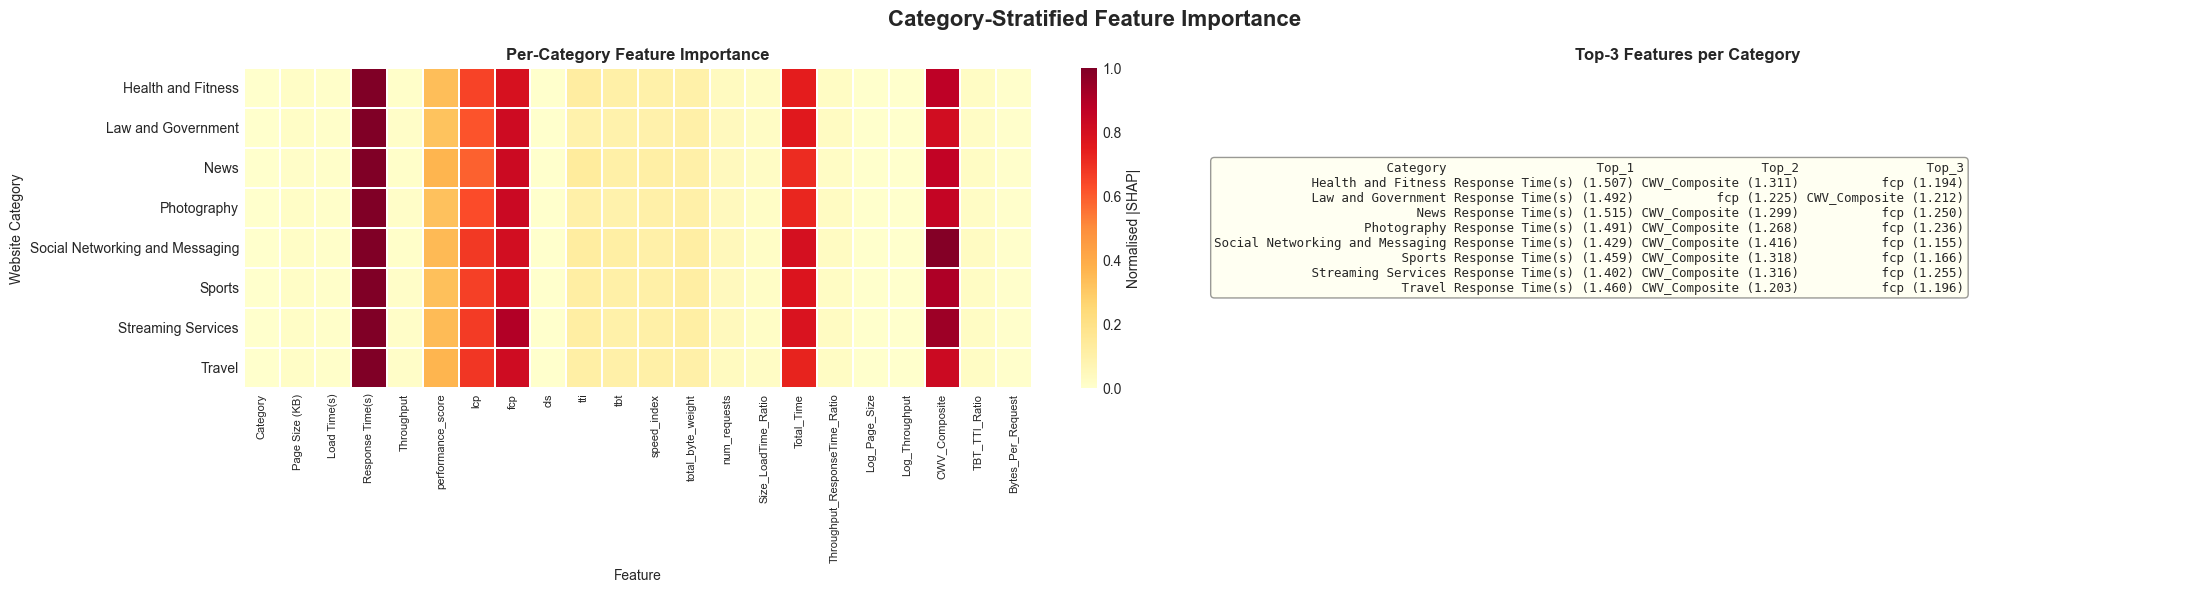


Features with SIGNIFICANTLY DIFFERENT importance across categories:
  - Category
  - Page Size (KB)
  - tti
  - Load Time(s)
  - cls
  - Size_LoadTime_Ratio
  - CWV_Composite
  - num_requests
  - Throughput

-> One-size-fits-all recommendations are SUB-OPTIMAL for these features.
   Category-specific optimization strategies should be considered.


In [21]:
# --- 7c. Category-Stratified Heatmap & Top Features per Category -----------

fig, axes = plt.subplots(1, 2, figsize=(22, max(6, len(cat_shap_df)*0.6)))
fig.suptitle('Category-Stratified Feature Importance',
             fontsize=16, fontweight='bold')

# 1. Heatmap
# Normalise per row (category) for comparability
cat_norm = cat_shap_df.div(cat_shap_df.max(axis=1), axis=0)
sns.heatmap(cat_norm, annot=False, cmap='YlOrRd', ax=axes[0],
            linewidths=0.3, cbar_kws={'label': 'Normalised |SHAP|'})
axes[0].set_title('Per-Category Feature Importance', fontweight='bold')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Website Category')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# 2. Top-3 features per category
summary_rows = []
for cat in cat_shap_df.index:
    top3 = cat_shap_df.loc[cat].nlargest(3)
    summary_rows.append({
        'Category': cat,
        'Top_1': f'{top3.index[0]} ({top3.iloc[0]:.3f})',
        'Top_2': f'{top3.index[1]} ({top3.iloc[1]:.3f})',
        'Top_3': f'{top3.index[2]} ({top3.iloc[2]:.3f})'
    })
summary_df = pd.DataFrame(summary_rows)

axes[1].axis('off')
tbl_text = summary_df.to_string(index=False)
axes[1].text(0.02, 0.5, tbl_text, fontsize=9, family='monospace',
             va='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.4))
axes[1].set_title('Top-3 Features per Category', fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretation
sig_features = kw_df[kw_df['Significant_0.05']]['Feature'].tolist()
if len(sig_features) > 0:
    print(f'\nFeatures with SIGNIFICANTLY DIFFERENT importance across categories:')
    for f in sig_features:
        print(f'  - {f}')
    print('\n-> One-size-fits-all recommendations are SUB-OPTIMAL for these features.')
    print('   Category-specific optimization strategies should be considered.')
else:
    print('\nNo statistically significant differences found. Feature importance is consistent across categories.')

---
## 8. NOVEL CONTRIBUTION 4 — Counterfactual Explanations

**Motivation:** While SHAP and LIME explain *why* a website was classified in a certain way,
they do not directly answer: *"What is the minimal set of changes to make this slow page fast?"*

Counterfactual explanations provide *actionable, sparse* change-sets — the smallest perturbation
to the input features that flips the model's prediction from the current (undesired) class to
the target (desired) class.

**Method:**
1. For each slow/medium website, solve a constrained optimisation that minimises feature-change
   magnitude while achieving prediction = "fast".
2. Enforce domain constraints (e.g., page size and load time cannot increase).
3. Aggregate: which features appear most frequently in counterfactual change-sets?
4. Compare counterfactual recommendations with Phase 2 prescriptive output.

In [24]:
# --- 8a. Counterfactual Generator (Growing-Spheres + Prototype Hybrid) ------

# Domain knowledge: directional constraints
SHOULD_DECREASE = {
    'Page Size (KB)', 'Load Time(s)', 'Response Time(s)',
    'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index',
    'total_byte_weight', 'Total_Time', 'Log_Page_Size',
    'CWV_Composite', 'TBT_TTI_Ratio', 'Bytes_Per_Request'
}
SHOULD_INCREASE = {
    'Throughput', 'performance_score', 'num_requests',
    'Size_LoadTime_Ratio', 'Throughput_ResponseTime_Ratio',
    'Log_Throughput'
}
FIXED_FEATURES = {'Category'}

FAST_CLASS = class_names.index('fast')

# Pre-compute fast prototypes for nearest-neighbour seeding
fast_mask = (y == FAST_CLASS)
X_fast    = X_scaled[fast_mask]

# Feature-index sets for direction constraints
decrease_idx = [i for i, fn in enumerate(feature_names) if fn in SHOULD_DECREASE]
increase_idx = [i for i, fn in enumerate(feature_names) if fn in SHOULD_INCREASE]
fixed_idx    = [i for i, fn in enumerate(feature_names) if fn in FIXED_FEATURES]


def generate_counterfactual(x_scaled, target_class=FAST_CLASS,
                            n_candidates=500, n_rounds=10,
                            sparsity_weight=0.05):
    """
    Hybrid counterfactual generator for tree-based models:
      1. Seed with nearest fast prototype (nearest-neighbour in target class).
      2. Growing-spheres random search: progressively larger perturbation
         radii with domain-aware directional constraints.
      3. Among successful candidates, pick the sparsest (fewest changes).

    Returns (cf_scaled, delta, changed_features, success).
    """
    x0 = x_scaled.copy().flatten()
    n_feat = len(x0)

    # 1. Nearest-prototype seed ------------------------------------------
    dists = np.linalg.norm(X_fast - x0, axis=1)
    nearest_proto = X_fast[np.argmin(dists)].copy()

    # Enforce direction constraints on prototype delta
    proto_delta = nearest_proto - x0
    for i in decrease_idx:
        proto_delta[i] = min(proto_delta[i], 0.0)   # only decrease
    for i in increase_idx:
        proto_delta[i] = max(proto_delta[i], 0.0)   # only increase
    for i in fixed_idx:
        proto_delta[i] = 0.0

    # Test prototype
    candidates = []
    cf_proto = (x0 + proto_delta).reshape(1, -1)
    if model.predict(cf_proto)[0] == target_class:
        changed = {feature_names[i]: proto_delta[i]
                   for i in range(n_feat) if abs(proto_delta[i]) > 0.01}
        candidates.append((cf_proto.flatten(), proto_delta.copy(), changed))

    # 2. Growing-spheres random search -----------------------------------
    rng = np.random.default_rng(42)
    for radius_scale in np.linspace(0.2, 3.0, n_rounds):
        # Generate random perturbations scaled by radius
        deltas = rng.normal(0, radius_scale, size=(n_candidates, n_feat))

        # Enforce direction constraints
        for i in decrease_idx:
            deltas[:, i] = -np.abs(deltas[:, i])
        for i in increase_idx:
            deltas[:, i] = np.abs(deltas[:, i])
        for i in fixed_idx:
            deltas[:, i] = 0.0

        # Also blend towards prototype direction (guided search)
        alpha = rng.uniform(0.0, 0.7, size=(n_candidates, 1))
        deltas = alpha * proto_delta + (1 - alpha) * deltas

        # Re-enforce constraints after blending
        for i in decrease_idx:
            deltas[:, i] = np.minimum(deltas[:, i], 0.0)
        for i in increase_idx:
            deltas[:, i] = np.maximum(deltas[:, i], 0.0)
        for i in fixed_idx:
            deltas[:, i] = 0.0

        cfs = x0 + deltas
        preds = model.predict(cfs)

        for j in np.where(preds == target_class)[0]:
            d = deltas[j]
            changed = {feature_names[i]: d[i]
                       for i in range(n_feat) if abs(d[i]) > 0.01}
            candidates.append((cfs[j].copy(), d.copy(), changed))

    if not candidates:
        return x0.reshape(1, -1), np.zeros(n_feat), {}, False

    # 3. Pick sparsest (fewest features changed) -------------------------
    best = min(candidates, key=lambda c: (len(c[2]),
                                          np.sum(np.abs(c[1]))))
    cf_scaled, delta, changed = best
    return cf_scaled.reshape(1, -1), delta, changed, True

print('Hybrid counterfactual generator defined (prototype + growing-spheres).')
print(f'Fast prototypes available: {len(X_fast)}')


Hybrid counterfactual generator defined (prototype + growing-spheres).
Fast prototypes available: 299


In [25]:
# --- 8b. Generate Counterfactuals for Non-Fast Websites ---------------------

# Select slow and medium samples
non_fast_mask = y != FAST_CLASS
non_fast_idx  = np.where(non_fast_mask)[0]

# Limit to a manageable number
MAX_CF = 100
np.random.seed(42)
cf_sample_idx = np.random.choice(non_fast_idx, size=min(MAX_CF, len(non_fast_idx)), replace=False)

print(f'Generating counterfactuals for {len(cf_sample_idx)} non-fast samples...')

cf_results = []
success_count = 0

for i, idx in enumerate(cf_sample_idx):
    cf_scaled, delta, changed, success = generate_counterfactual(X_scaled[idx:idx+1])
    cf_results.append({
        'idx': idx,
        'original_class': class_names[y[idx]],
        'cf_class': class_names[model.predict(cf_scaled)[0]],
        'success': success,
        'n_changed': len(changed),
        'changed_features': changed,
        'delta_l1': np.sum(np.abs(delta))
    })
    if success:
        success_count += 1
    if (i + 1) % 25 == 0:
        print(f'  {i+1}/{len(cf_sample_idx)} done  (success rate: {success_count/(i+1)*100:.1f}%)')

cf_success_rate = success_count / len(cf_sample_idx) * 100
print(f'\nCounterfactual generation complete.')
print(f'  Success rate: {success_count}/{len(cf_sample_idx)} ({cf_success_rate:.1f}%)')
print(f'  Mean features changed (successful): '
      f'{np.mean([r["n_changed"] for r in cf_results if r["success"]]):.1f}')

Generating counterfactuals for 100 non-fast samples...
  25/100 done  (success rate: 100.0%)
  50/100 done  (success rate: 100.0%)
  75/100 done  (success rate: 100.0%)
  100/100 done  (success rate: 100.0%)

Counterfactual generation complete.
  Success rate: 100/100 (100.0%)
  Mean features changed (successful): 13.2


Feature Frequency in Successful Counterfactuals:
                      Feature  Frequency  Pct_Counterfactuals  Mean_Change  Std_Change
                          lcp         92               92.000       -0.891       0.781
                          fcp         89               89.000       -0.921       0.647
                CWV_Composite         89               89.000       -0.552       0.429
            performance_score         87               87.000        0.570       0.401
                  speed_index         78               78.000       -0.613       0.462
                          tti         76               76.000       -0.472       0.395
             Response Time(s)         75               75.000       -0.889       0.710
                   Total_Time         75               75.000       -0.547       0.452
            total_byte_weight         72               72.000       -0.656       0.569
                 Load Time(s)         65               65.000       -0.478       

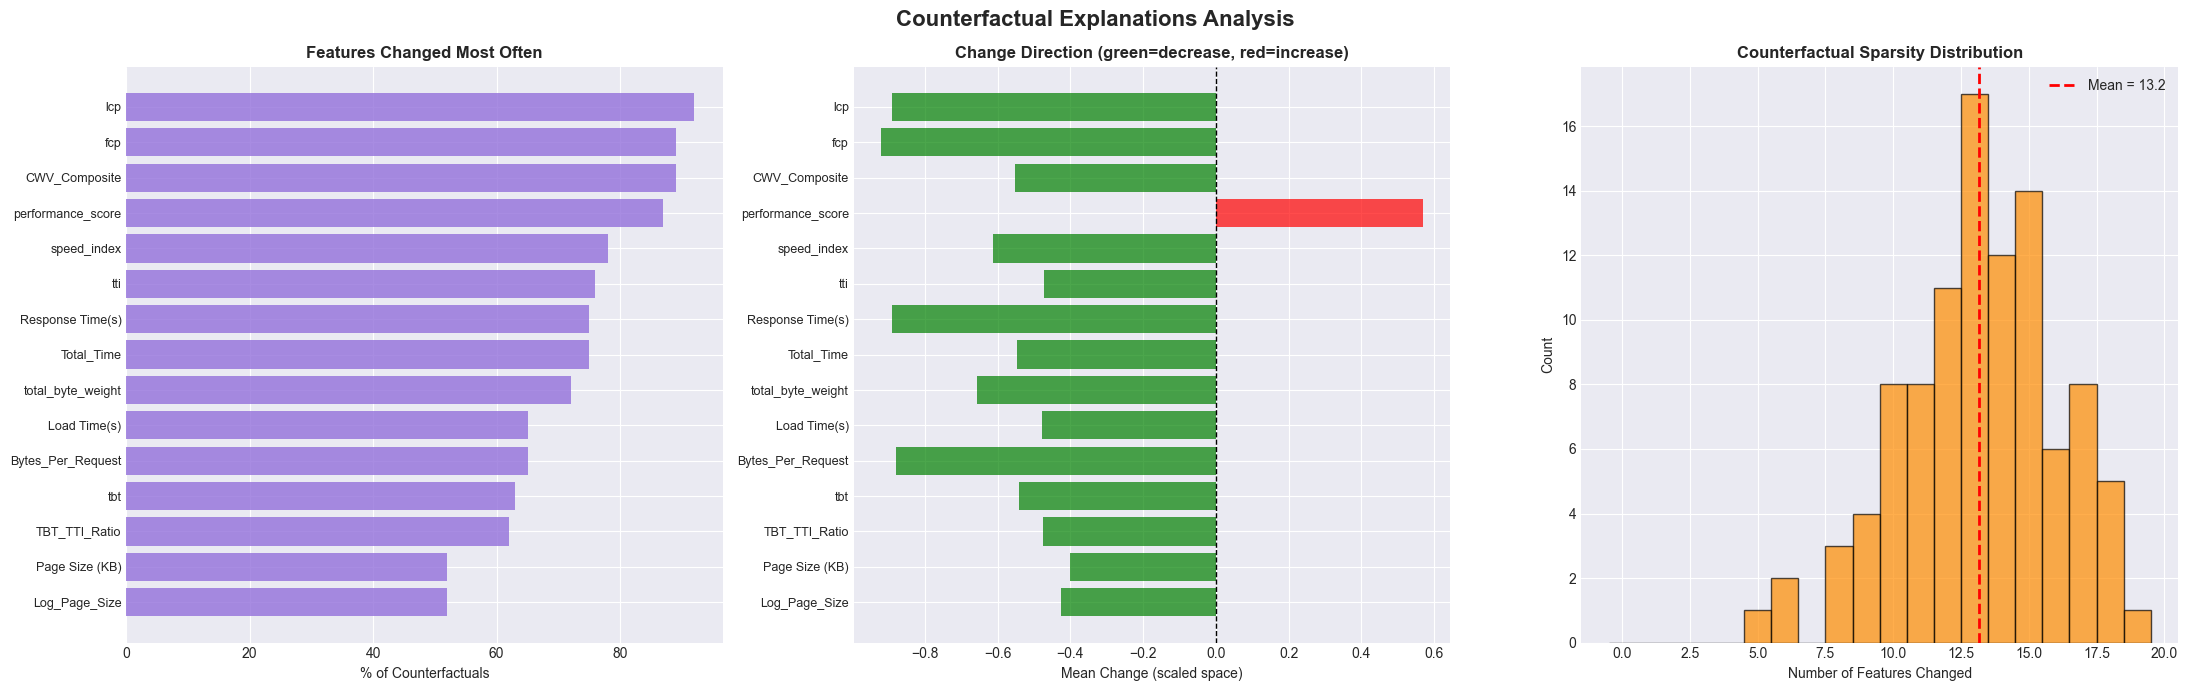


--- Example Counterfactuals ---

Sample 803 (slow -> fast): 15 features changed
  Response Time(s)                     delta = -2.4181
  fcp                                  delta = -2.3068
  Total_Time                           delta = -1.5204
  lcp                                  delta = -1.1246
  cls                                  delta = -1.1111
  Load Time(s)                         delta = -0.9567
  CWV_Composite                        delta = -0.6990
  total_byte_weight                    delta = -0.6021
  performance_score                    delta = +0.5429
  Log_Page_Size                        delta = -0.4347
  Page Size (KB)                       delta = -0.3709
  tti                                  delta = -0.3139
  Bytes_Per_Request                    delta = -0.2338
  speed_index                          delta = -0.2031
  Size_LoadTime_Ratio                  delta = +0.1416

Sample 473 (medium -> fast): 14 features changed
  Size_LoadTime_Ratio                  delta

In [26]:
# --- 8c. Counterfactual Analysis & Visualisation ----------------------------

# Aggregate: which features appear most in successful counterfactuals?
feature_change_count = {fn: 0 for fn in feature_names}
feature_change_magnitude = {fn: [] for fn in feature_names}

successful_cfs = [r for r in cf_results if r['success']]

for r in successful_cfs:
    for fn, delta_val in r['changed_features'].items():
        feature_change_count[fn] += 1
        feature_change_magnitude[fn].append(delta_val)

# Sort by frequency
cf_freq = pd.DataFrame([
    {
        'Feature': fn,
        'Frequency': feature_change_count[fn],
        'Pct_Counterfactuals': feature_change_count[fn] / max(len(successful_cfs), 1) * 100,
        'Mean_Change': np.mean(feature_change_magnitude[fn]) if feature_change_magnitude[fn] else 0,
        'Std_Change': np.std(feature_change_magnitude[fn]) if len(feature_change_magnitude[fn]) > 1 else 0
    }
    for fn in feature_names
]).sort_values('Frequency', ascending=False).reset_index(drop=True)

print('Feature Frequency in Successful Counterfactuals:')
print(cf_freq.to_string(index=False, float_format='{:.3f}'.format))

# --- Visualise ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Counterfactual Explanations Analysis', fontsize=16, fontweight='bold')

# 1. Feature frequency in counterfactuals
cf_top = cf_freq[cf_freq['Frequency'] > 0].head(15)
axes[0].barh(range(len(cf_top)), cf_top['Pct_Counterfactuals'],
             color='mediumpurple', alpha=0.8)
axes[0].set_yticks(range(len(cf_top)))
axes[0].set_yticklabels(cf_top['Feature'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('% of Counterfactuals')
axes[0].set_title('Features Changed Most Often', fontweight='bold')

# 2. Mean change direction
cf_nonzero = cf_freq[cf_freq['Frequency'] > 0].head(15)
colors_dir = ['green' if v < 0 else 'red' for v in cf_nonzero['Mean_Change']]
axes[1].barh(range(len(cf_nonzero)), cf_nonzero['Mean_Change'], color=colors_dir, alpha=0.7)
axes[1].set_yticks(range(len(cf_nonzero)))
axes[1].set_yticklabels(cf_nonzero['Feature'], fontsize=9)
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel('Mean Change (scaled space)')
axes[1].set_title('Change Direction (green=decrease, red=increase)', fontweight='bold')

# 3. Sparsity distribution
n_changed_dist = [r['n_changed'] for r in successful_cfs]
axes[2].hist(n_changed_dist, bins=range(0, max(n_changed_dist)+2),
             color='darkorange', alpha=0.7, edgecolor='black', align='left')
axes[2].set_xlabel('Number of Features Changed')
axes[2].set_ylabel('Count')
axes[2].set_title('Counterfactual Sparsity Distribution', fontweight='bold')
axes[2].axvline(np.mean(n_changed_dist), color='red', ls='--', lw=2,
                label=f'Mean = {np.mean(n_changed_dist):.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print a few example counterfactuals
print('\n--- Example Counterfactuals ---')
for r in successful_cfs[:3]:
    print(f'\nSample {r["idx"]} ({r["original_class"]} -> {r["cf_class"]}): '
          f'{r["n_changed"]} features changed')
    for fn, dv in sorted(r['changed_features'].items(), key=lambda x: abs(x[1]), reverse=True):
        print(f'  {fn:35s}  delta = {dv:+.4f}')

In [27]:
# --- 8d. Compare Counterfactual vs SHAP Feature Rankings --------------------

# Counterfactual importance: frequency of change
cf_importance = cf_freq.set_index('Feature')['Pct_Counterfactuals']
cf_importance = cf_importance / (cf_importance.max() + 1e-12)  # normalise

# SHAP importance (already have)
shap_importance_norm = normalise(shap_global)

# Rank comparison
cf_rank   = stats.rankdata(-cf_importance.values)
shap_rank = stats.rankdata(-shap_importance_norm)

tau_cf_shap, p_cf_shap = stats.kendalltau(cf_rank, shap_rank)
rho_cf_shap, p_rho     = stats.spearmanr(cf_rank, shap_rank)

print('Counterfactual vs SHAP Feature Ranking:')
print(f"  Kendall's tau: {tau_cf_shap:.3f}  (p={p_cf_shap:.4f})")
print(f"  Spearman's rho: {rho_cf_shap:.3f}  (p={p_rho:.4f})")

if tau_cf_shap > 0.5:
    print('  -> Strong agreement: SHAP and counterfactuals identify the same key features.')
elif tau_cf_shap > 0.3:
    print('  -> Moderate agreement: some features differ in importance between methods.')
else:
    print('  -> Weak agreement: counterfactuals highlight different actionable features than SHAP.')
    print('     This is expected — SHAP measures influence, counterfactuals measure actionability.')

Counterfactual vs SHAP Feature Ranking:
  Kendall's tau: 0.079  (p=0.6108)
  Spearman's rho: 0.081  (p=0.7185)
  -> Weak agreement: counterfactuals highlight different actionable features than SHAP.
     This is expected — SHAP measures influence, counterfactuals measure actionability.


---
## 9. Domain Validation & Data Quality

In [28]:
# --- 9a. Correlation Validation Against Domain Knowledge --------------------

# Features that should show POSITIVE correlation with Performance Code
# (0=fast, 1=medium, 2=slow) — i.e., higher value -> worse performance
expected_positive = [
    'Load Time(s)', 'Response Time(s)', 'Page Size (KB)',
    'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index',
    'total_byte_weight'
]
# Throughput should be NEGATIVE (higher = better)
expected_negative = ['Throughput']

perf_code = target_encoder.transform(df_work['Performance_Label'].values)
df_corr = X_original.copy()
df_corr['Performance_Code'] = perf_code

validation = []
for feat in expected_positive + expected_negative:
    if feat in df_corr.columns:
        corr = df_corr[['Performance_Code', feat]].corr().iloc[0, 1]
        expected = 'POSITIVE' if feat in expected_positive else 'NEGATIVE'
        actual   = 'POSITIVE' if corr > 0 else 'NEGATIVE'
        status   = 'PASS' if expected == actual else 'FAIL'
        validation.append({'Feature': feat, 'Expected': expected,
                          'Correlation': corr, 'Status': status})

val_df = pd.DataFrame(validation)
passed = (val_df['Status'] == 'PASS').sum()
total  = len(val_df)

print(f'Domain Validation: {passed}/{total} passed ({passed/total*100:.1f}%)\n')
print(val_df.to_string(index=False, float_format='{:.4f}'.format))

# Data quality
print(f'\nDataset: {len(X_original)} samples, {X_original.shape[1]} features')
print(f'Missing values: {X_original.isnull().sum().sum()}')
print(f'Duplicates:     {X_original.duplicated().sum()}')
print(f'Class balance:  {dict(zip(*np.unique(y, return_counts=True)))}')

Domain Validation: 9/11 passed (81.8%)

          Feature Expected  Correlation Status
     Load Time(s) POSITIVE       0.3672   PASS
 Response Time(s) POSITIVE       0.4607   PASS
   Page Size (KB) POSITIVE      -0.0368   FAIL
              lcp POSITIVE       0.6078   PASS
              fcp POSITIVE       0.6194   PASS
              cls POSITIVE       0.1538   PASS
              tti POSITIVE       0.6030   PASS
              tbt POSITIVE       0.4858   PASS
      speed_index POSITIVE       0.5557   PASS
total_byte_weight POSITIVE       0.5331   PASS
       Throughput NEGATIVE       0.1827   FAIL

Dataset: 885 samples, 22 features
Missing values: 0
Duplicates:     0
Class balance:  {np.int64(0): np.int64(299), np.int64(1): np.int64(271), np.int64(2): np.int64(315)}


---
## 10. Comprehensive Report & Export

In [29]:
print('='*80)
print('PHASE 3 EXPLAINABILITY ANALYSIS — COMPREHENSIVE REPORT')
print('='*80)

# 1. Model summary
print(f'\n1. MODEL SUMMARY')
print(f'   Model:     {model_pkg["model_name"]}')
print(f'   Accuracy:  {model_pkg["metrics"]["Accuracy"]:.4f}')
print(f'   Features:  {len(feature_names)}')
print(f'   Dataset:   {len(X_original)} samples')

# 2. Global importance (consensus)
print(f'\n2. MULTI-METHOD CONSENSUS (Novel Contribution 1)')
print(f'   Fidelity weights: SHAP={w_shap_n:.3f}, LIME={w_lime_n:.3f}, Perm={w_perm_n:.3f}')
print(f'   Top-5 consensus features:')
for i, row in consensus_df.head(5).iterrows():
    print(f'     {i+1}. {row["Feature"]:30s}  score={row["Consensus"]:.4f}  '
          f'CI=[{row["CI_Low"]:.3f}, {row["CI_High"]:.3f}]')

# Rank correlations
print(f'\n   Rank correlations:')
for lbl, t, r in zip(corr_labels, tau_vals, rho_vals):
    print(f'     {lbl.replace(chr(10), " "):18s}  tau={t:.3f}  rho={r:.3f}')

# 3. Stability
print(f'\n3. EXPLANATION STABILITY (Novel Contribution 2)')
print(f'   LIME Jaccard stability:   {lime_stability_index:.4f} +/- {lime_stability_std:.4f}')
print(f'   SHAP perturbation drift:  {shap_mean_drift:.4f} +/- {shap_std_drift:.4f}')
print(f'   SHAP-LIME agreement by class:')
for cn in class_names:
    vals = tau_per_class[cn]
    if vals:
        print(f'     {cn:8s}: tau={np.mean(vals):.3f} +/- {np.std(vals):.3f}')

# 4. Category-stratified
print(f'\n4. CATEGORY-STRATIFIED EXPLAINABILITY (Novel Contribution 3)')
print(f'   Categories analysed:     {len(cat_shap_df)}')
print(f'   Features with significant inter-category differences (p<0.05): {n_sig}')
if sig_features:
    for f in sig_features[:5]:
        print(f'     - {f}')

# 5. Counterfactuals
print(f'\n5. COUNTERFACTUAL EXPLANATIONS (Novel Contribution 4)')
print(f'   Samples processed:   {len(cf_sample_idx)}')
print(f'   Success rate:         {cf_success_rate:.1f}%')
if successful_cfs:
    print(f'   Mean features changed: {np.mean([r["n_changed"] for r in successful_cfs]):.1f}')
    print(f'   CF vs SHAP agreement:  tau={tau_cf_shap:.3f}')
    print(f'   Top actionable features (by counterfactual frequency):')
    for _, row in cf_freq.head(5).iterrows():
        if row['Frequency'] > 0:
            print(f'     - {row["Feature"]:30s}  {row["Pct_Counterfactuals"]:.1f}%')

# 6. Domain validation
print(f'\n6. DOMAIN VALIDATION')
print(f'   Pattern validation:  {passed}/{total} passed ({passed/total*100:.1f}%)')

print('\n' + '='*80)
print('PHASE 3 COMPLETE')
print('='*80)

PHASE 3 EXPLAINABILITY ANALYSIS — COMPREHENSIVE REPORT

1. MODEL SUMMARY
   Model:     XGBoost
   Accuracy:  0.9060
   Features:  22
   Dataset:   885 samples

2. MULTI-METHOD CONSENSUS (Novel Contribution 1)
   Fidelity weights: SHAP=0.438, LIME=0.123, Perm=0.438
   Top-5 consensus features:
     1. Response Time(s)                score=0.9939  CI=[0.951, 1.000]
     2. CWV_Composite                   score=0.8190  CI=[0.707, 1.000]
     3. fcp                             score=0.8023  CI=[0.766, 0.852]
     4. Total_Time                      score=0.6868  CI=[0.632, 0.750]
     5. lcp                             score=0.4918  CI=[0.307, 0.646]

   Rank correlations:
     SHAP vs LIME        tau=0.633  rho=0.766
     SHAP vs Perm        tau=0.565  rho=0.703
     LIME vs Perm        tau=0.599  rho=0.767

3. EXPLANATION STABILITY (Novel Contribution 2)
   LIME Jaccard stability:   0.8764 +/- 0.1048
   SHAP perturbation drift:  0.3278 +/- 0.2544
   SHAP-LIME agreement by class:
     fast

In [30]:
# --- Export all results to CSV -----------------------------------------------

# 1. Consensus ranking
consensus_df.to_csv('phase3_consensus_feature_ranking.csv', index=False)

# 2. SHAP per-class importance
mean_shap_per_class.to_csv('phase3_shap_feature_importance.csv')

# 3. Kruskal-Wallis results
kw_df.to_csv('phase3_category_kruskal_wallis.csv', index=False)

# 4. Category SHAP profiles
cat_shap_df.to_csv('phase3_category_shap_profiles.csv')

# 5. Counterfactual frequency
cf_freq.to_csv('phase3_counterfactual_feature_frequency.csv', index=False)

# 6. Domain validation
val_df.to_csv('phase3_validation_results.csv', index=False)

# 7. Stability metrics
stability_summary = pd.DataFrame([{
    'LIME_Jaccard_Mean': lime_stability_index,
    'LIME_Jaccard_Std': lime_stability_std,
    'SHAP_Drift_Mean': shap_mean_drift,
    'SHAP_Drift_Std': shap_std_drift,
    'SHAP_Fidelity': shap_fidelity,
    'LIME_Mean_R2': lime_mean_r2,
    'CF_SHAP_Kendall_Tau': tau_cf_shap,
    'CF_Success_Rate': cf_success_rate
}])
stability_summary.to_csv('phase3_stability_metrics.csv', index=False)

# 8. Correlation analysis
corr_export = pd.DataFrame({
    'Feature': feature_names,
    'Correlation_with_Perf': [df_corr[['Performance_Code', fn]].corr().iloc[0,1]
                              if fn in df_corr.columns else np.nan
                              for fn in feature_names]
})
corr_export.to_csv('phase3_correlation_analysis.csv', index=False)

print('Exported files:')
for f in [
    'phase3_consensus_feature_ranking.csv',
    'phase3_shap_feature_importance.csv',
    'phase3_category_kruskal_wallis.csv',
    'phase3_category_shap_profiles.csv',
    'phase3_counterfactual_feature_frequency.csv',
    'phase3_validation_results.csv',
    'phase3_stability_metrics.csv',
    'phase3_correlation_analysis.csv'
]:
    print(f'  {f}')

Exported files:
  phase3_consensus_feature_ranking.csv
  phase3_shap_feature_importance.csv
  phase3_category_kruskal_wallis.csv
  phase3_category_shap_profiles.csv
  phase3_counterfactual_feature_frequency.csv
  phase3_validation_results.csv
  phase3_stability_metrics.csv
  phase3_correlation_analysis.csv
